# Cardiac Digital Twin Summer School (CaDiTSS)

# Cardiac Image Analysis and Mesh Fitting

In this practical session, we will build a deep learning-based processing pipeline for cine cardiac magnetic resonance (CMR) image analysis and mesh fitting. This practical session will work through the following steps:

- Automated CMR image segmentation.
- CMR image-derived phenotypes calculation and analysis.
- Bi-ventricular heart mesh template construction.
- Bi-ventricular heart mesh fitting using a deep learning-based approach.

# Part I. Cardiac MRI Segmentation and Analysis

![Cardiac MR segmentation with U-Net](https://raw.githubusercontent.com/m-qiang/CaDiTSS/main/figures/segmentation.png)

In [ ]:
import os
import glob
import random
import numpy as np
from tqdm.notebook import tqdm
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## 1. ACDC Dataset

In this practical session, we will use the **ACDC (Automated Cardiac Diagnosis Challenge)** dataset (https://www.creatis.insa-lyon.fr/Challenge/acdc/databases.html), a widely used public dataset containing **short-axis view cine CMR** from 150 subjects, capturing the beating heart over multiple time frames throughout the cardiac cycle. The 150 subjects are divided into 5 diagnostic groups:

- **NOR** - 30 normal subjects

- **MINF** - 30 patients with previous myocardial infarction (ejection fraction of the left ventricle lower than 40% and several myocardial segments with abnormal contraction)

- **DCM** - 30 patients with dilated cardiomyopathy (diastolic left ventricular volume >100 mL/m$^2$ and an ejection fraction of the left ventricle lower than 40%)

- **HCM** - 30 patients with hypertrophic cardiomyopathy (left ventricular cardiac mass high than 110 g/m$^2$, several myocardial segments with a thickness higher than 15 mm in diastole and a normal ejecetion fraction)

- **RV** - 30 patients with abnormal right ventricle (volume of the right ventricular cavity higher than 110 mL/m$^2$ or ejection fraction of the rigth ventricle lower than 40%)

For each case, manual segmentations are provided at two clinically important phases of the cardiac cycle:

- **End-diastole (ED)** – when the ventricles reach maximum filling
- **End-systole (ES)** – when the ventricles reach maximum contraction

The segmentation masks identify three main cardiac structures:
- `0` - Background
- `1` - **Right ventricular (RV) blood pool**
- `2` - **Left ventricular myocardium (MYO)**
- `3` - **Left ventricular (LV) blood pool**

### Download

The cell below downloads a copy of the dataset from **Hugging Face** (https://huggingface.co/datasets/msepulvedagodoy/acdc/tree/main) and stores it in the local `./ACDC` directory.

In [ ]:
os.environ["HF_HUB_DISABLE_XET"] = "1"
from huggingface_hub import snapshot_download

data_dir = snapshot_download(
    repo_id="msepulvedagodoy/ACDC",
    repo_type="dataset",
    local_dir="./ACDC"
)

print(f"Dataset downloaded to: {data_dir}")

### File structure

After downloading, the ACDC dataset has the following structure:

```text
ACDC/
├── training/
│   ├── patient001/
│   │   ├── Info.cfg
│   │   ├── patient001_4d.nii.gz
│   │   ├── patient001_frame01.nii.gz
│   │   ├── patient001_frame01_gt.nii.gz
│   │   ├── patient001_frame12.nii.gz
│   │   └── patient001_frame12_gt.nii.gz
│   ├── patient002/
│   ├── patient003/
│   └── ...
│
└── testing/
    ├── patient101/
    ├── patient102/
    └── ...
```

The CMR image data are stored as **NIfTI** format `nii.gz`.

In [ ]:
!ls ./ACDC/training/patient001

Info.cfg	       patient001_frame01_gt.nii.gz  patient001_frame12.nii.gz
MANDATORY_CITATION.md  patient001_frame01.nii.gz
patient001_4d.nii.gz   patient001_frame12_gt.nii.gz


In [ ]:
!cat ./ACDC/training/patient039/Info.cfg

ED: 1
ES: 10
Group: HCM
Height: 175.0
NbFrame: 28
Weight: 100.0


In [ ]:
img_3d = nib.load("./ACDC/training/patient001/patient001_frame01.nii.gz").get_fdata()
img_4d = nib.load("./ACDC/training/patient001/patient001_4d.nii.gz").get_fdata()

# (X,Y,Z,T)
print(img_3d.shape)
print(img_4d.shape)

(216, 256, 10)
(216, 256, 10, 30)


### Visualisation

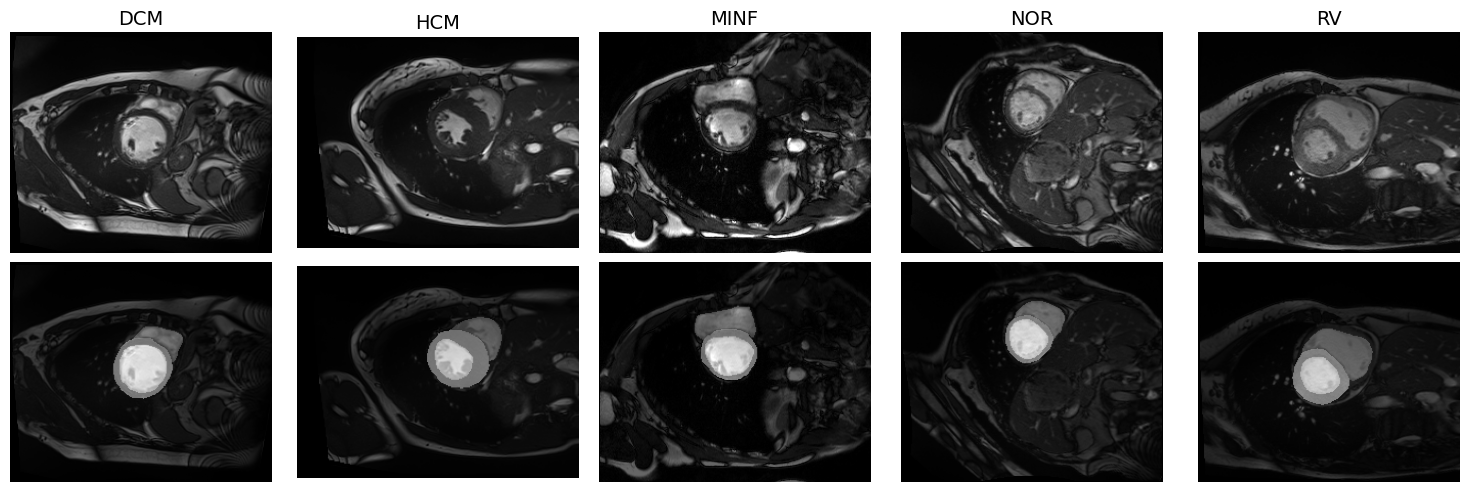

In [ ]:
group_list = ["DCM", "HCM", "MINF", "NOR", "RV"]
patient_list = ["001", "029", "045", "060", "098"]

plt.figure(figsize=(15,5))
for i in range(len(group_list)):
    group = group_list[i]
    patient = patient_list[i]
    img = nib.load("./ACDC/training/patient"+patient+"/patient"+patient+"_frame01.nii.gz").get_fdata()
    seg = nib.load("./ACDC/training/patient"+patient+"/patient"+patient+"_frame01_gt.nii.gz").get_fdata()
    zid = img.shape[-1]//2 - 1  # visualise the middle slice

    plt.subplot(2,5,i+1)
    plt.imshow(img[:,:,zid], cmap="gray")
    plt.title(group, fontsize=14)
    plt.axis("off")
    plt.subplot(2,5,i+6)
    plt.imshow(img[:,:,zid], cmap="gray")
    plt.imshow(seg[:,:,zid], alpha=0.6, vmin=0, vmax=3, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Split the dataset

The ACDC dataset is divided into separate **training** and **validation** sets at the **patient level**.

The `split_patients` function randomly shuffles the patient directories and assigns a proportion of them to the training set. This avoids potential data leakage.

The `get_pairs_from_patients` function then collects the CMR volumes and their corresponding ground-truth segmentations from each patient directory.

In [ ]:
def split_patients(
    data_dir: str,
    train_ratio: float = 0.8,
    seed: int = 42
) -> tuple[list[str], list[str]]:
    """
    Split patient folders into training and validation sets.

    Args
    - data_dir: directory containing the ACDC patient folders.
    - train_ratio: ratio of patients used for training.
    - seed: random seed for reproducibility.

    Returns
    - train_patient_paths: training patient paths.
    - val_patient_paths: validation patient paths.
    """
    patient_paths = sorted(
        glob.glob(os.path.join(data_dir, "patient*"))
    )

    random.seed(seed)
    random.shuffle(patient_paths)

    split_idx = int(len(patient_paths) * train_ratio)

    train_patient_paths = patient_paths[:split_idx]
    val_patient_paths = patient_paths[split_idx:]

    return train_patient_paths, val_patient_paths


def get_pairs_from_patients(
    patient_paths: list[str]
) -> tuple[list[str], list[str]]:
    """
    Collect paired CMR image and segmentation paths from patient paths.

    Args
    - patient_paths: list of ACDC patient paths.

    Returns
    - img_paths: paths to CMR images.
    - seg_paths: paths to corresponding ground-truth segmentations.
    """

    img_paths = []
    seg_paths = []

    for patient_path in patient_paths:

        # Find all ground-truth segmentation files
        seg_files = sorted(glob.glob(os.path.join(patient_path, "*_gt.nii.gz")))

        for seg_path in seg_files:
            # The corresponding MRI has the same filename without the "_gt" suffix
            img_path = seg_path.replace("_gt.nii.gz", ".nii.gz")

            # Add the pair only if the MRI file exists
            if os.path.exists(img_path):
                img_paths.append(img_path)
                seg_paths.append(seg_path)

    return img_paths, seg_paths

In [ ]:
data_dir = "./ACDC/training"
train_patient_paths, val_patient_paths = split_patients(data_dir)
train_img_paths, train_seg_paths = get_pairs_from_patients(train_patient_paths)
val_img_paths, val_seg_paths = get_pairs_from_patients(val_patient_paths)

print("Example CMR image path:", train_img_paths[0])
print("Example segmentation path:", train_img_paths[0])
print("Number of training pairs:", len(train_img_paths))
print("Number of validation pairs:", len(val_img_paths))

Example CMR image path: ./ACDC/training/patient043/patient043_frame01.nii.gz
Example segmentation path: ./ACDC/training/patient043/patient043_frame01.nii.gz
Number of training pairs: 160
Number of validation pairs: 40


### PyTorch dataloader
We now create separate `ACDCDataset` objects for the training and validation sets. Each dataset:

- loads the 3D CMR image and segmentation volumes,
- normalises the MRI intensities,
- extracts multiple 2D short-axis slices,
- resizes each slice to `256 × 256`,
- stores the resulting tensors for use during training.

The `DataLoader` then groups these slices into mini-batches that can be passed to the neural network.


In [ ]:
class ACDCDataset(Dataset):
    """
    PyTorch dataset for 2D cardiac MR segmentation.

    Each 3D ACDC CMR volume is normalised, split into 2D short-axis slices,
    resized, and stored as a PyTorch tensor.

    Args
    - img_paths: paths to the NIfTI MRI volumes.
    - seg_paths: paths to the corresponding segmentation masks.
    - img_size: output size (height, width) of each 2D slice.
    - upper_percentile: intensity percentile used to clip bright MRI outliers.
    """

    def __init__(
        self,
        img_paths,
        seg_paths,
        img_size=(256, 256),
        upper_percentile=99.5
    ):
        self.img_list = []
        self.seg_list = []

        for img_path, seg_path in tqdm(zip(img_paths, seg_paths)):
            # Load MRI and segmentation volumes (X,Y,Z) using nibabel
            img = nib.load(img_path).get_fdata().astype(np.float32)
            seg = nib.load(seg_path).get_fdata().astype(np.int8)

            # ---------------------------------------------------------
            # Min-max intensity normalisation
            # ---------------------------------------------------------
            # Clip very bright voxels to reduce the effect of outliers.
            upper = np.percentile(img, upper_percentile)
            img = np.clip(img, 0, upper)

            # Scale MRI intensities approximately to [0, 1].
            img /= img.max() + 1e-8

            # ---------------------------------------------------------
            # Convert the 3D volume into 2D CMR slices
            # ---------------------------------------------------------
            for z in range(img.shape[2]):
                img_slice = img[:, :, z]  # (X, Y, Z) -> (X, Y)
                seg_slice = seg[:, :, z]  # (X, Y, Z) -> (X, Y)

                # Convert NumPy arrays to PyTorch tensors (X, Y) -> (1, 1, X, Y)
                img_tensor = torch.from_numpy(img_slice)[None, None]
                seg_tensor = torch.from_numpy(seg_slice)[None, None]

                # Resize image and segmentation by interpolation
                # F.interpolate expects: (batch, channel, height, width)
                img_tensor = F.interpolate(
                    img_tensor,
                    size=img_size,
                    mode="bilinear"
                )

                seg_tensor = F.interpolate(
                    seg_tensor.float(),
                    size=img_size,
                    mode="nearest"
                ).long()

                # Store: img -> (1, H, W), seg -> (H, W)
                self.img_list.append(img_tensor[0])
                self.seg_list.append(seg_tensor[0,0])

    def __len__(self):
        """Return the number of 2D slices in the dataset."""
        return len(self.img_list)

    def __getitem__(self, idx):
        """Return one MRI slice and its segmentation."""
        return self.img_list[idx], self.seg_list[idx]

In [ ]:
# create ACDCDataset
train_dataset = ACDCDataset(
    train_img_paths,
    train_seg_paths,
    img_size=(256, 256),
    upper_percentile=99.5
)

val_dataset = ACDCDataset(
    val_img_paths,
    val_seg_paths,
    img_size=(256, 256),
    upper_percentile=99.5
)

# wrapped by PyTorch DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Number of training slices:", len(train_dataset))
print("Number of validation slices:", len(val_dataset))

# an example of a batch
imgs, segs = next(iter(val_loader))
print("CMR image batch shape:", imgs.shape)
print("Segmentation batch shape:", segs.shape)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Number of training slices: 1526
Number of validation slices: 376
CMR image batch shape: torch.Size([8, 1, 256, 256])
Segmentation batch shape: torch.Size([8, 256, 256])


## 2. U-Net Model

We will use a **2D U-Net** to segment the cardiac structures for each short-axis MRI slice. U-Net is an encoder–decoder convolutional neural network (https://arxiv.org/abs/1505.04597) with **skip connections** designed for image segmentation:

- **Encoder** - The encoder progressively reduces the spatial resolution of the input while increasing the number of feature channels. This allows the network to learn increasingly abstract representations of the cardiac anatomy.

- **Decoder** - The decoder progressively restores the original spatial resolution using transposed convolutions. At each decoder level, the upsampled features are concatenated with features from the corresponding encoder level through **skip connections**, which preserve fine spatial information that may otherwise be lost during downsampling.

In [ ]:
class ConvBlock2D(nn.Module):
    """
    Two convolutional layers:
    (Conv2D -> InstanceNorm -> ReLU) x 2
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1
            ),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)

### Task 1: Create your own U-Net
Below, we provide the code for a basic **2D convolutional neural network (CNN)**. The goal of this task is to extend this network into a **U-Net** by adding **skip connections** between the encoders and decoders. The difference between a standard CNN and a U-Net is illustrated in the following figure.

![U-Net architecture](https://raw.githubusercontent.com/m-qiang/CaDiTSS/main/figures/unet.png)

Hint: The skip connections can be implemented using PyTorch `torch.cat` function (https://docs.pytorch.org/docs/2.14/generated/torch.cat.html) to concatenate the encoder features with the corresponding decoder features along the channel dimension.

In [ ]:
class UNet2D(nn.Module):
    """
    2D U-Net for multi-class CMR segmentation.

    Input
    - x: input CMR slice (B, 1, X, Y)

    Output
    - logits: output logits for four classes (B, 4, X, Y)
    """

    def __init__(self, in_channels=1, out_channels=4):
        super().__init__()

        # ---------------------------------------------------------
        # Encoder
        # ---------------------------------------------------------
        self.enc1 = ConvBlock2D(in_channels, 16)
        self.enc2 = ConvBlock2D(16, 32, stride=2)
        self.enc3 = ConvBlock2D(32, 64, stride=2)
        self.enc4 = ConvBlock2D(64, 128, stride=2)

        # ---------------------------------------------------------
        # Bottleneck
        # ---------------------------------------------------------
        self.bottleneck = ConvBlock2D(128, 256, stride=2)

        # ---------------------------------------------------------
        # Decoder
        # ---------------------------------------------------------
        self.up4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec4 = ConvBlock2D(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvBlock2D(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock2D(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvBlock2D(32, 16)

        # ---------------------------------------------------------
        # Output layer
        # ---------------------------------------------------------
        self.out = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder + skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Return class logits
        return self.out(d1)

In [ ]:
# ---------------------------------------------------------
# Test your U-Net model
# ---------------------------------------------------------
model = UNet2D(in_channels=1, out_channels=4)

x = torch.randn(2, 1, 256, 256)
logits = model(x)

print("Input shape: ", x.shape)
print("Output shape:", logits.shape)

# Expected output:
expected_shape = (2, 4, 256, 256)

assert logits.shape == expected_shape, (
    f"Unexpected output shape: {logits.shape}. "
    f"Expected: {expected_shape}"
)

print("Output shape is correct.")

Input shape:  torch.Size([2, 1, 256, 256])
Output shape: torch.Size([2, 4, 256, 256])
Output shape is correct.


## 3. Training 2D U-Net for CMR Segementation

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Devcie:", device)

# initialise model
model = UNet2D(in_channels=1, out_channels=4).to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

Devcie: cuda


In [ ]:
def train(
    model,
    data_loader,
    optimizer,
    criterion,
    device = "cuda"
) -> float:
    """
    Train the model for one epoch.

    Returns
    - train_loss: average loss over all mini-batches.
    """
    # enable training mode
    model.train()

    total_loss = 0.0

    for img, seg in data_loader:

        # move data to CPU/GPU
        img = img.to(device)
        seg = seg.to(device)

        # clear gradients from the previous iteration
        optimizer.zero_grad()

        # forward pass
        logits = model(img)

        # compute segmentation loss
        loss = criterion(logits, seg)

        # backpropagation
        loss.backward()

        # update model parameters
        optimizer.step()

        total_loss += loss.item()

    # average loss over all training batches
    train_loss = total_loss / len(data_loader)

    return train_loss

In [ ]:
@torch.no_grad()
def validate(
    model,
    data_loader,
    criterion,
    device = "cuda"
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    # enable evaluation mode
    model.eval()

    total_loss = 0.0

    for img, seg in data_loader:

        # move data to CPU/GPU
        img = img.to(device)
        seg = seg.to(device)

        # forward pass
        logits = model(img)

        # compute validation loss
        loss = criterion(logits, seg)
        total_loss += loss.item()

    # average loss over all validation batches
    val_loss = total_loss / len(data_loader)

    # select one example from the last validation batch
    # (B, 1, X, Y) -> (X, Y)
    img_val = img[0,0].cpu().numpy()

    # convert logits to predicted class labels
    # (B, 4, X, Y) -> (X, Y)
    seg_pred = torch.argmax(logits[0], dim=0).cpu().numpy()

    # ground truth segmentation
    # (B, X, Y) -> (X, Y)
    seg_gt = seg[0].cpu().numpy()

    return val_loss, img_val, seg_pred, seg_gt

### Start training

In [ ]:
num_epochs = 20
best_val_loss = float("inf")

# create directory to save checkpoints
os.makedirs("./model", exist_ok=True)

train_curve = []
val_curve = []

# start training
for epoch in tqdm(range(num_epochs)):
    # ---------------------------------------------------------
    # Training
    # ---------------------------------------------------------
    train_loss = train(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------
    val_loss, img_val, seg_pred, seg_gt = validate(
        model,
        val_loader,
        criterion,
        device,
    )

    train_curve.append(train_loss)
    val_curve.append(val_loss)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # ---------------------------------------------------------
    # Save the best model checkpoint
    # ---------------------------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print("Save model checkpoint.")
        torch.save(
            model.state_dict(),
            "./model/acdc_seg_unet.pth"
        )

    # ---------------------------------------------------------
    # Visualisation
    # ---------------------------------------------------------
    plt.figure(figsize=(11,3))
    plt.subplot(1,4,1)
    plt.imshow(img_val, cmap="gray")
    plt.axis("off")
    plt.title("Image")

    plt.subplot(1,4,2)
    plt.imshow(img_val, cmap="gray")
    plt.imshow(seg_pred, alpha=0.6, vmin=0, vmax=3, cmap="gray")
    plt.axis("off")
    plt.title("Prediction")

    plt.subplot(1,4,3)
    plt.imshow(img_val, cmap="gray")
    plt.imshow(seg_gt, alpha=0.6, vmin=0, vmax=3, cmap="gray")
    plt.axis("off")
    plt.title("Ground Truth")

    plt.subplot(1,4,4)
    plt.plot(train_curve, label='train')
    plt.plot(val_curve, label='val')
    plt.xticks(np.arange(0,num_epochs+1,2))
    plt.ylim(0,1.0)
    plt.legend()
    plt.title("Train & Val Loss Curve")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 4. Evaluation of 3D CMR segmentation
We evaulate the performance of the 2D segmentation U-Net on complete **3D CMR volumes** using **Dice similarity coefficient (DSC or Dice score)**. The Dice score is a commonly used metric for evaluating image segmentation. It measures the spatial overlap between two segmentations:


$$\mathrm{Dice} = \frac{2|P \cap G|}{|P| + |G|}$$

where $P$ is the predicted segmentation, $G$ is the ground-truth segmentation, and $|\cdot|$ is the number of pixels/voxels. A Dice score of `1` indicates perfect overlap, while a score of `0` indicates no overlap. For ACDC test set, we calculate Dice separately for the three cardiac structures:
- `Label 1` - RV blood pool (RV)
- `Label 2` - LV myocardium (MYO)
- `Label 3` - LV blood pool (LV)


### Task 2: Implement the Dice score

In [ ]:
def dice_score(
    pred: np.ndarray,
    target: np.ndarray,
    num_classes: int = 4,
    eps: float = 1e-8
) -> list[float]:
    """
    Compute Dice scores for each foreground class in a 3D volume.

    Args
    - pred: predicted 3D segmentation with shape (X, Y, Z).
    - target: ground-truth 3D segmentation with shape (X, Y, Z).
    - num_classes: total number of segmentation classes, including background.

    Returns
    - scores: Dice score for each foreground class.
    """

    scores = []

    # Skip class 0 (background)
    for c in range(1, num_classes):
        # predicted segmentation mask for class c
        pred_c = (pred == c)
        # ground-truth segmentation mask for class c
        target_c = (target == c)

        # intersection between two segmentations
        intersection = (pred_c & target_c).sum()
        denominator = pred_c.sum() + target_c.sum()

        dice = 2.0 * intersection / (denominator + eps)
        scores.append(dice)

    return scores

In [ ]:
# ---------------------------------------------------------
# Test your Dice score
# ---------------------------------------------------------
pred = np.ones([256, 256, 12])
target_pos = np.ones([256, 256, 12])
target_neg = np.zeros([256, 256, 12])
target_half = np.ones([256, 256, 12])
target_half[:128] = 0

dice_pos = dice_score(pred, target_pos)[0]
dice_neg = dice_score(pred, target_neg)[0]
dice_half = dice_score(pred, target_half)[0]

assert np.isclose(dice_pos, 1.0), (
    f"Dice test failed: identical volumes should give a Dice score of 1.0, "
    f"but got {dice_pos}.")

assert np.isclose(dice_neg, 0.0), (
    f"Dice test failed: non-overlapping volumes should give a Dice score of 0.0, "
    f"but got {dice_neg}.")

assert np.isclose(dice_half, 2/3), (
    f"Dice test failed: partial-overlap example should give a Dice score of 0.6667, "
    f"but got {dice_half}.")

print("All Dice score tests passed.")

All Dice score tests passed.


### Start test

In [ ]:
# ---------------------------------------------------------
# Predict 3D CMR segmentation
# ---------------------------------------------------------
@torch.no_grad()
def predict_3d(
    model: nn.Module,
    img: np.ndarray,
    img_size: tuple[int, int] = (256, 256),
    upper_percentile: float = 99.5,
    device: str = "cuda",
) -> np.ndarray:
    """
    Predict the segmentation of a complete 3D CMR volume.

    Returns
    - pred: predicted segmentation with the original volume shape (X, Y, Z).
    """

    model.eval()

    # original spatial size
    X, Y, Z = img.shape

    # Apply the same intensity normalisation used during training
    upper = np.percentile(img, upper_percentile)
    img = np.clip(img, 0, upper)
    img /= img.max() + 1e-8

    # empty volume for predicted segmentation
    pred = np.zeros_like(img)

    # predict one slice at a time
    for z in range(Z):
        img_slice = img[:, :, z]

        # (X, Y) -> (1, 1, X, Y)
        img_tensor = torch.from_numpy(img_slice)[None, None]

        # resize to the size used during training
        img_tensor = F.interpolate(
            img_tensor,
            size=img_size,
            mode="bilinear"
        ).to(device)

        # forward pass
        logits = model(img_tensor)

        # resize predicted logits back to the original spatial resolution
        logits = F.interpolate(
            logits,
            size=(X, Y),
            mode="bilinear"
        )

        # (1, 4, X, Y) -> (X, Y)
        seg_pred = torch.argmax(logits, dim=1)[0]

        pred[:, :, z] = seg_pred.cpu().numpy()

    return pred.astype(np.int8)

In [ ]:
# ---------------------------------------------------------
# Load U-Net model
# ---------------------------------------------------------
# initialise model
model = UNet2D(in_channels=1, out_channels=4).to(device)
# load your best checkpoint
model.load_state_dict(
    torch.load("./model/acdc_seg_unet.pth", map_location=device)
)

# ---------------------------------------------------------
# Collect test ACDC data paths
# ---------------------------------------------------------
test_patient_paths = sorted(glob.glob("./ACDC/testing/patient*"))
test_img_paths, test_seg_paths = get_pairs_from_patients(test_patient_paths)
print("Number of test pairs:", len(test_img_paths))

# ---------------------------------------------------------
# Run test
# ---------------------------------------------------------
test_dice = []

for img_path, seg_path in tqdm(zip(test_img_paths, test_seg_paths)):
    img = nib.load(img_path).get_fdata().astype(np.float32)
    seg_gt = nib.load(seg_path).get_fdata().astype(np.int8)

    # Predict complete 3D volume
    seg_pred = predict_3d(model, img, device=device)

    # Compute Dice scores
    dice = dice_score(seg_pred, seg_gt, num_classes=4)
    test_dice.append(dice)

# ---------------------------------------------------------
# Final Dice score
# ---------------------------------------------------------
test_dice = np.stack(test_dice)
print(f"RV Dice:   {test_dice.mean(0)[0]:.3f}")
print(f"MYO Dice:  {test_dice.mean(0)[1]:.3f}")
print(f"LV Dice:   {test_dice.mean(0)[2]:.3f}")
print(f"Mean Dice: {test_dice.mean():.3f}")


Number of test pairs: 100


0it [00:00, ?it/s]

RV Dice:   0.792
MYO Dice:  0.799
LV Dice:   0.875
Mean Dice: 0.822


## 5. 3D+t CMR Image Analysis

After evaluating the 3D CMR segmentation, we extend the analysis to the full **3D+t cine cardiac MR sequence**. In this final section, we will:

1. Predict **3D+t cardiac segmentations** across the full cardiac cycle.
2. Compute **bi-ventricular volume curves** for the left and right ventricles.
3. Derive **image-derived phenotypes (IDPs)** from the ventricular volume curves.

Patient ID: patient102
ED: 1
ES: 13
Group: NOR
Height: 156.0
NbFrame: 30
Weight: 75.0

4D CMR volume shape: (216, 256, 8, 30)


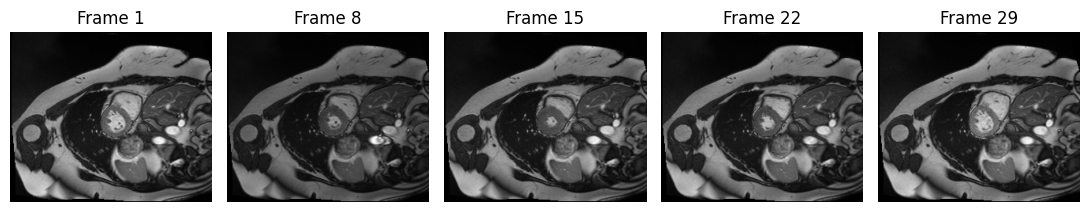

In [ ]:
# ---------------------------------------------------------
# Load test ACDC 4D volume
# ---------------------------------------------------------
test_paths = sorted(glob.glob("./ACDC/testing/patient*"))

# pick a patient
patient_path = test_paths[1]
patient_id = patient_path.split("/")[-1]
print("Patient ID:", patient_id)

# print patient's information
with open(os.path.join(patient_path, "Info.cfg"), "r") as f:
    print(f.read())

# load 3D+t CMR volume
img_path = os.path.join(patient_path, patient_id+"_4d.nii.gz")
img_4d_nii = nib.load(img_path)
img_4d = img_4d_nii.get_fdata().astype(np.float32)
print("4D CMR volume shape:", img_4d.shape)

# visualise 3D+t CMR volume
T = img_4d.shape[-1]
z = 2  # slice approaching the base
i = 1
plt.figure(figsize=(11,3))
for t in range(0, T, 7):
    plt.subplot(1, T//7+1, i)
    plt.imshow(img_4d[:, :, z, t], cmap="gray")
    plt.axis("off")
    plt.title(f"Frame {t+1}")
    i += 1
plt.tight_layout()
plt.show()

### Task 3: Compute bi-ventricular volume curves

Given a 3D+t CMR sequence with dimensions `(X, Y, Z, T)`, where `T` represents time across the cardiac cycle, our goal is to compute the left and right ventricular volumes (mL) at each time frame. The volume curves are computed in two steps:

1. **Predict the 3D+t segmentation** - For each time frame, use the `predict_3d` function to predict the 3D segmentation mask. Repeating this for all frames produces a 3D+t segmentation sequence.

2. **Compute ventricular volumes** - Each voxel in the segmentation represents a physical volume determined by the voxel spacing stored in the NIfTI header. For a given structure, the volume at each time frame is calculated as:
$$\mathrm{V = N_{voxel} \times V_{voxel} \times 10^{-3} ~(mL),}$$
where $\mathrm{N_{voxel}}$ is the number of voxels belonging to the cardiac structure, $\mathrm{V_{voxel}}$ is the volume of one voxel in `mm³`, and $10^{-3}$ converts the volume from `mm³` to `mL`. Applying this calculation to all time frames produces the **LV and RV volume curves** across the full cardiac cycle.

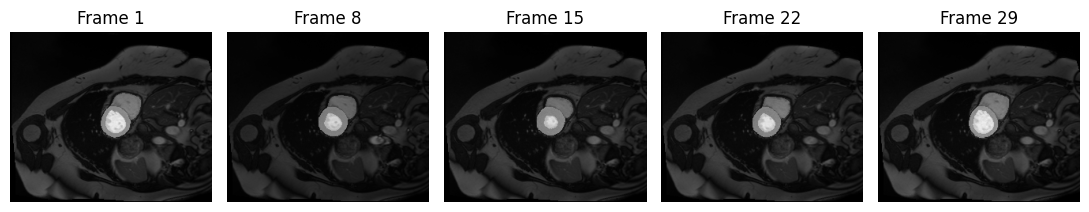

In [ ]:
# ---------------------------------------------------------
# Step 1. Predict 3D+t segmentation
# ---------------------------------------------------------
seg_4d = np.zeros_like(img_4d)  # (X,Y,Z,T)
T = img_4d.shape[-1]
for t in range(T):
    img_3d = img_4d[..., t]
    seg_3d = predict_3d(model, img_3d, device=device)
    seg_4d[..., t] = seg_3d

# visualise segmentation
T = img_4d.shape[-1]
z = 2  # slice approaching the base
i = 1
plt.figure(figsize=(11,3))
for t in range(0, T, 7):
    plt.subplot(1, T//7+1, i)
    plt.imshow(img_4d[:, :, z, t], cmap="gray")
    plt.imshow(seg_4d[:, :, z, t], alpha=0.6, vmin=0, vmax=3, cmap="gray")
    plt.axis("off")
    plt.title(f"Frame {t+1}")
    i += 1
plt.tight_layout()
plt.show()

Voxel size: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0)) mm
Voxel volume: 24.414 mm³


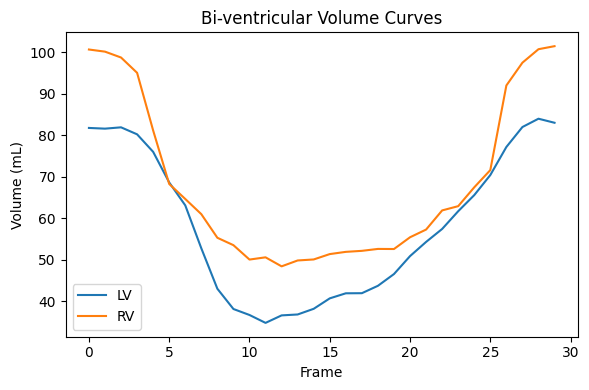

In [ ]:
# ---------------------------------------------------------
# Step 2. Compute bi-ventricular volume curves
# ---------------------------------------------------------
# read voxel size from NIfTI header file
voxel_size = img_4d_nii.header.get_zooms()[:3]
print(f"Voxel size: {voxel_size} mm")

# compute the volume of each voxel
voxel_volume = np.prod(voxel_size)
print(f"Voxel volume: {voxel_volume:.3f} mm³")

# compute bi-ventricular volumes across all time frames
# ACDC labels:
# 1 = RV blood pool
# 2 = LV myocardium
# 3 = LV blood pool
volume_lv = (seg_4d==3).sum(axis=(0,1,2)) * voxel_volume * 1e-3
volume_myo = (seg_4d==2).sum(axis=(0,1,2)) * voxel_volume * 1e-3
volume_rv = (seg_4d==1).sum(axis=(0,1,2)) * voxel_volume * 1e-3

# plot volume curves
plt.figure(figsize=(6,4))
plt.plot(volume_lv, label='LV')
plt.plot(volume_rv, label='RV')
plt.xlabel("Frame")
plt.ylabel("Volume (mL)")
plt.title("Bi-ventricular Volume Curves")
plt.legend()
plt.tight_layout()
plt.show()

### Task 4: Compute CMR image-derived phenotypes (IDPs)

The predicted 3D+t cardiac segmentation allows us to derive quantitative clinical measures of cardiac structure and function, known as **image-derived phenotypes (IDPs)**, which can be used to characterise different patterns of cardiac disease.

First, we identify two important phases of the cardiac cycle from the predicted LV volume curve:

- **End-diastole (ED)** - The phase when the left ventricle contains its largest volume of blood.
- **End-systole (ES)** - The phase when the left ventricle contains its smallest volume of blood after contraction.

These phases can be estimated directly from the LV volume curve:

- **ED** - Frame with the **maximum LV volume**.
- **ES** - Frame with the **minimum LV volume**.

Then, for each ventricle, we calculate:

- **End-diastolic volume (EDV)** - The volume of the ventricle at end-diastole.
- **End-systolic volume (ESV)** - The volume of the ventricle at end-systole.
- **Stroke volume (SV)** - The amount of blood ejected during one cardiac cycle: $\mathrm{SV = EDV - ESV~(mL)}$.
- **Ejection fraction (EF)** - The percentage of ejected blood: $\mathrm{EF = \frac{SV}{EDV} \times 100}~(\%)$.

The segmentation also provides the volume of the LV myocardium. The **LV myocardial mass (LVM)** is estimated from the myocardial volume at end-diastole using $\mathrm{LVM= V_{myo} \times \rho_{myo}~(g)}$, where $\mathrm{V_{myo}}$ is the LV myocardial volume and
$\mathrm{\rho_{myo}=1.05~g/mL}$ is the assumed myocardial tissue density.

In [ ]:
# ---------------------------------------------------------
# Compute CMR image-derived phenotypes (IDPs)
# ---------------------------------------------------------
# identify end-diastolic (ED) and end-systolic (ES) phases
# from the maximum and minimum LV volumes
ed_idx = np.argmax(volume_lv)
es_idx = np.argmin(volume_lv)

# LV IDPs
lvedv = volume_lv[ed_idx]  # end-diastolic volume
lvesv = volume_lv[es_idx]  # end-systolic volume
lvsv = lvedv - lvesv       # stroke volume
lvef = 100 * lvsv / lvedv  # ejection fraction

# RV IDPs
rvedv = volume_rv[ed_idx]  # end-diastolic volume
rvesv = volume_rv[es_idx]  # end-systolic volume
rvsv = rvedv - rvesv       # stroke volume
rvef = 100 * rvsv / rvedv  # ejection fraction

# LV myocardial mass
density = 1.05
volume_myo_ed = volume_myo[ed_idx]
lvm = volume_myo_ed * density  # myocardial volume (mL) × density (g/mL)

print(f"LV mass: {lvm:.1f} g")
print()
print(f"LV EDV:  {lvedv:.1f} mL")
print(f"LV ESV:  {lvesv:.1f} mL")
print(f"LV SV:   {lvsv:.1f} mL")
print(f"LV EF:   {lvef:.1f} %")
print()
print(f"RV EDV:  {rvedv:.1f} mL")
print(f"RV ESV:  {rvesv:.1f} mL")
print(f"RV SV:   {rvsv:.1f} mL")
print(f"RV EF:   {rvef:.1f} %")


LV mass: 80.2 g

LV EDV:  84.0 mL
LV ESV:  34.8 mL
LV SV:   49.2 mL
LV EF:   58.6 %

RV EDV:  100.7 mL
RV ESV:  50.6 mL
RV SV:   50.1 mL
RV EF:   49.8 %
